# Bare Metal Rebuild + Transport Geometry — Notebook Version

This notebook merges the **bare-metal rebuild** pipeline with the new **transport / state / schedule / capacity** layer.

It is organized as one continuous bench notebook:

1. **Bare-metal core**  
   - SHA-256 rails
   - round engine
   - forward schedule expansion
   - 16-step reverse rebuild from $W_{16..31}$ to $W_{0..15}$

2. **Hardware observables**  
   - seam XOR
   - seam full
   - carry residual
   - universal seed $B$
   - jumper diagnostic $\Sigma_0(a)=\operatorname{Maj}(a,b,c)$

3. **GF(2) geometry**  
   - Jacobian
   - rank
   - nullspace
   - parity checks
   - seam augmentation tests

4. **Transport geometry layer**  
   - direct state transport gradient
   - schedule echo growth
   - path multiplicity scaffold
   - capacity-gated projection law
   - state-space closure vs schedule-space persistence

The notebook's high-level split is:

$$
\boxed{
\text{Entry} \to \text{Branch} \to \text{Saturate} \to \text{Reset}
}
$$

and the load-bearing transport statement is:

$$
\boxed{
\text{visible state support grows only while unsaturated capacity remains.}
}
$$

The notebook is self-contained and notebook-first.


## 1. Core setup

Define the rails, operators, schedule functions, and low-level utility helpers.


In [1]:

import math
import random
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt

MASK32 = 0xFFFFFFFF

H0 = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

K = [
    0x428A2F98, 0x71374491, 0xB5C0FBCF, 0xE9B5EBA5, 0x3956C25B, 0x59F111F1, 0x923F82A4, 0xAB1C5ED5,
    0xD807AA98, 0x12835B01, 0x243185BE, 0x550C7DC3, 0x72BE5D74, 0x80DEB1FE, 0x9BDC06A7, 0xC19BF174,
    0xE49B69C1, 0xEFBE4786, 0x0FC19DC6, 0x240CA1CC, 0x2DE92C6F, 0x4A7484AA, 0x5CB0A9DC, 0x76F988DA,
    0x983E5152, 0xA831C66D, 0xB00327C8, 0xBF597FC7, 0xC6E00BF3, 0xD5A79147, 0x06CA6351, 0x14292967,
    0x27B70A85, 0x2E1B2138, 0x4D2C6DFC, 0x53380D13, 0x650A7354, 0x766A0ABB, 0x81C2C92E, 0x92722C85,
    0xA2BFE8A1, 0xA81A664B, 0xC24B8B70, 0xC76C51A3, 0xD192E819, 0xD6990624, 0xF40E3585, 0x106AA070,
    0x19A4C116, 0x1E376C08, 0x2748774C, 0x34B0BCB5, 0x391C0CB3, 0x4ED8AA4A, 0x5B9CCA4F, 0x682E6FF3,
    0x748F82EE, 0x78A5636F, 0x84C87814, 0x8CC70208, 0x90BEFFFA, 0xA4506CEB, 0xBEF9A3F7, 0xC67178F2,
]

# Fix typo in K[3]
K[3] = 0xE9B5DBA5

def u32(x: int) -> int:
    return x & MASK32

def rotr(x: int, n: int) -> int:
    x &= MASK32
    return ((x >> n) | ((x << (32 - n)) & MASK32)) & MASK32

def Sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

def Ch(e: int, f: int, g: int) -> int:
    return u32((e & f) ^ ((~e) & g))

def Maj(a: int, b: int, c: int) -> int:
    return u32((a & b) ^ (a & c) ^ (b & c))

def parse_hex_words(text: str, n: int) -> List[int]:
    parts = [p.strip() for p in text.replace("\n", ",").split(",") if p.strip()]
    if len(parts) != n:
        raise ValueError(f"expected {n} words, got {len(parts)}")
    out = []
    for p in parts:
        q = p.lower()
        if q.startswith("0x"):
            q = q[2:]
        out.append(int(q, 16) & MASK32)
    return out

def words_to_hex(words: List[int]) -> List[str]:
    return [f"0x{w:08x}" for w in words]


## 2. Schedule engine

Forward expansion and the 16-step reverse rebuild.


In [2]:

def expand_schedule_from_w0_15(w0_15: List[int]) -> List[int]:
    if len(w0_15) != 16:
        raise ValueError("need 16 words for W0..15")
    W = [u32(w) for w in w0_15] + [0] * 48
    for t in range(16, 64):
        W[t] = u32(sigma1(W[t - 2]) + W[t - 7] + sigma0(W[t - 15]) + W[t - 16])
    return W

def rebuild_w0_15_from_w16_31(w16_31: List[int]) -> Tuple[List[int], List[int]]:
    if len(w16_31) != 16:
        raise ValueError("need 16 words for W16..31")
    W = [0] * 32
    for i, w in enumerate(w16_31, start=16):
        W[i] = u32(w)
    for t in range(31, 15, -1):
        W[t - 16] = u32(W[t] - sigma1(W[t - 2]) - W[t - 7] - sigma0(W[t - 15]))
    return W[:16], W


## 3. Round engine and hardware observables

This cell defines:
- round update
- seam XOR
- seam full
- carry residual
- universal seed $B$
- jumper diagnostic


In [3]:

def round_terms(state: List[int], w: int, r: int) -> Tuple[int, int]:
    a, b, c, d, e, f, g, h = state
    t1 = u32(h + Sigma1(e) + Ch(e, f, g) + K[r] + w)
    t2 = u32(Sigma0(a) + Maj(a, b, c))
    return t1, t2

def round_step(state: List[int], w: int, r: int) -> List[int]:
    a, b, c, d, e, f, g, h = state
    t1, t2 = round_terms(state, w, r)
    return [
        u32(t1 + t2),
        a,
        b,
        c,
        u32(d + t1),
        e,
        f,
        g,
    ]

def seam_xor_word(state: List[int]) -> int:
    a, b, c, d, e, f, g, h = state
    return u32(Sigma0(a) ^ Maj(a, b, c) ^ d)

def seam_full_word(state: List[int]) -> int:
    a, b, c, d, e, f, g, h = state
    return u32(Sigma0(a) + Maj(a, b, c) + d)

def carry_residual_word(state: List[int]) -> int:
    return u32(seam_full_word(state) ^ seam_xor_word(state))

def seed_B_word(state: List[int]) -> int:
    a, b, c, d, e, f, g, h = state
    return u32(Sigma0(a) & Maj(a, b, c))

def jumper_hit(state: List[int]) -> bool:
    a, b, c, d, e, f, g, h = state
    return Sigma0(a) == Maj(a, b, c)

def run_rounds(W: List[int], rounds: int = 64, state0: List[int] = None):
    state = (state0 or H0).copy()
    out = [state.copy()]
    for r in range(rounds):
        state = round_step(state, W[r], r)
        out.append(state.copy())
    return out

def observe_rounds(W: List[int], rounds: int, state0: List[int] = None):
    state = (state0 or H0).copy()
    rows = []
    for r in range(rounds):
        t1, t2 = round_terms(state, W[r], r)
        rows.append({
            "r": r,
            "state": state.copy(),
            "t1": t1,
            "t2": t2,
            "seam_xor": seam_xor_word(state),
            "seam_full": seam_full_word(state),
            "carry_residual": carry_residual_word(state),
            "seed_B": seed_B_word(state),
            "jump": jumper_hit(state),
        })
        state = round_step(state, W[r], r)
    return rows


## 4. Sanity anchors

Prove the basic bare-metal identities.


In [4]:

_, t2_0 = round_terms(H0.copy(), 0, 0)
print(f"T2_0^(0) = 0x{t2_0:08x}")
assert t2_0 == 0x08909AE5

for W0 in [0, 1, 0x80000000, 0x12345678, 0xFFFFFFFF]:
    base = round_step(H0.copy(), 0, 0)
    live = round_step(H0.copy(), W0, 0)
    t1_base, _ = round_terms(H0.copy(), 0, 0)
    t1_live, _ = round_terms(H0.copy(), W0, 0)
    assert ((t1_live - t1_base) & MASK32) == (W0 & MASK32)
    assert ((live[0] - base[0]) & MASK32) == (W0 & MASK32)
    assert ((live[4] - base[4]) & MASK32) == (W0 & MASK32)

print("Verified:")
print("  • T2_0^(0) ground witness")
print("  • T1_0 - T1_0^(0) = W0")
print("  • first-step displacement into a/e")


T2_0^(0) = 0x08909ae5
Verified:
  • T2_0^(0) ground witness
  • T1_0 - T1_0^(0) = W0
  • first-step displacement into a/e


## 5. Bare-metal rebuild check

Forward-expand `W0..15`, then rebuild it from `W16..31`.


In [5]:

w0_15_text = ",".join(["0x00000000"] * 16)
w0_15 = parse_hex_words(w0_15_text, 16)
W = expand_schedule_from_w0_15(w0_15)
rebuilt_w0_15, _ = rebuild_w0_15_from_w16_31(W[16:32])

print("Original W0_15:")
print(words_to_hex(W[:16]))
print("\nRebuilt W0_15:")
print(words_to_hex(rebuilt_w0_15))
print("\nMatch:", all(u32(a) == u32(b) for a, b in zip(W[:16], rebuilt_w0_15)))
assert all(u32(a) == u32(b) for a, b in zip(W[:16], rebuilt_w0_15))


Original W0_15:
['0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000']

Rebuilt W0_15:
['0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000']

Match: True


## 6. GF(2) seam geometry

This is the linearized seam/Jacobian layer.


In [6]:

def bits_of_word(x: int, width: int = 32) -> np.ndarray:
    return np.array([(x >> i) & 1 for i in range(width)], dtype=np.uint8)

def flatten_words(words: List[int]) -> np.ndarray:
    return np.concatenate([bits_of_word(w) for w in words], axis=0)

def seam_observable_from_w6(w6: List[int], basis: str = "seam_xor") -> np.ndarray:
    rows = observe_rounds(w6, rounds=6)
    if basis == "seam_xor":
        words = [row["seam_xor"] for row in rows]
    elif basis == "seam_full":
        words = [row["seam_full"] for row in rows]
    elif basis == "carry_residual":
        words = [row["carry_residual"] for row in rows]
    elif basis == "seed_B":
        words = [row["seed_B"] for row in rows]
    elif basis == "seam_plus_d":
        words = []
        for row in rows:
            words.append(row["seam_xor"])
            words.append(row["state"][3])
    elif basis == "seam_plus_a":
        words = []
        for row in rows:
            words.append(row["seam_xor"])
            words.append(row["state"][0])
    elif basis == "seam_plus_e":
        words = []
        for row in rows:
            words.append(row["seam_xor"])
            words.append(row["state"][4])
    else:
        raise ValueError(f"unknown basis {basis}")
    return flatten_words(words)

def build_jacobian_w6(basis: str = "seam_xor") -> np.ndarray:
    y0 = seam_observable_from_w6([0] * 6, basis=basis)
    J = np.zeros((len(y0), 192), dtype=np.uint8)
    col = 0
    for j in range(6):
        for b in range(32):
            w6 = [0] * 6
            w6[j] = 1 << b
            y = seam_observable_from_w6(w6, basis=basis)
            J[:, col] = y0 ^ y
            col += 1
    return J

def gf2_rref(A: np.ndarray):
    A = (A.copy() & 1).astype(np.uint8)
    m, n = A.shape
    pivots = []
    row = 0
    for col in range(n):
        pivot = None
        for r in range(row, m):
            if A[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        if pivot != row:
            A[[row, pivot]] = A[[pivot, row]]
        for r in range(m):
            if r != row and A[r, col]:
                A[r] ^= A[row]
        pivots.append(col)
        row += 1
        if row == m:
            break
    return A, pivots

def gf2_rank(A: np.ndarray) -> int:
    _, pivots = gf2_rref(A)
    return len(pivots)

def gf2_nullspace_basis(A: np.ndarray) -> np.ndarray:
    R, pivots = gf2_rref(A)
    m, n = R.shape
    pivot_set = set(pivots)
    free_cols = [j for j in range(n) if j not in pivot_set]
    basis = []
    for fc in free_cols:
        v = np.zeros(n, dtype=np.uint8)
        v[fc] = 1
        for i, pc in enumerate(pivots):
            if R[i, fc]:
                v[pc] = 1
        basis.append(v)
    if not basis:
        return np.zeros((n, 0), dtype=np.uint8)
    return np.stack(basis, axis=1)

def gf2_left_nullspace_basis(A: np.ndarray) -> np.ndarray:
    return gf2_nullspace_basis(A.T)

basis = "seam_xor"
J = build_jacobian_w6(basis)
rank = gf2_rank(J)
N = gf2_nullspace_basis(J)
H = gf2_left_nullspace_basis(J).T

print("basis =", basis)
print("shape =", J.shape)
print("rank =", rank)
print("nullity =", J.shape[1] - rank)
print("left-nullity =", J.shape[0] - rank)
print("nullspace basis shape =", N.shape)
print("parity check shape =", H.shape)


basis = seam_xor
shape = (192, 192)
rank = 157
nullity = 35
left-nullity = 35
nullspace basis shape = (192, 35)
parity check shape = (35, 192)


## 7. Augmented seam tests

Measure whether adding retention or live seam channels changes the rank.


In [7]:

for basis in ["seam_xor", "seam_plus_d", "seam_plus_a", "seam_plus_e"]:
    Jb = build_jacobian_w6(basis)
    rb = gf2_rank(Jb)
    print(f"{basis:12s} -> shape {Jb.shape}, rank {rb}/{Jb.shape[1]}, nullity {Jb.shape[1]-rb}")


seam_xor     -> shape (192, 192), rank 157/192, nullity 35
seam_plus_d  -> shape (384, 192), rank 158/192, nullity 34
seam_plus_a  -> shape (384, 192), rank 160/192, nullity 32
seam_plus_e  -> shape (384, 192), rank 160/192, nullity 32


## 8. Transport geometry — direct state gradient

This section gives a simple **early-window state transport probe**:

- perturb one source word,
- compare states against the zero baseline,
- measure early-state Hamming activity over a fixed prefix of rounds.


W[ 0] early-window energy = 1503
W[ 1] early-window energy = 1426
W[ 2] early-window energy = 1379
W[ 3] early-window energy = 1164
W[ 4] early-window energy = 1063
W[ 5] early-window energy = 956
W[ 6] early-window energy = 773
W[ 7] early-window energy = 709
W[ 8] early-window energy = 574
W[ 9] early-window energy = 390
W[10] early-window energy = 291
W[11] early-window energy = 160
W[12] early-window energy = 93
W[13] early-window energy = 22
W[14] early-window energy = 10
W[15] early-window energy = 0


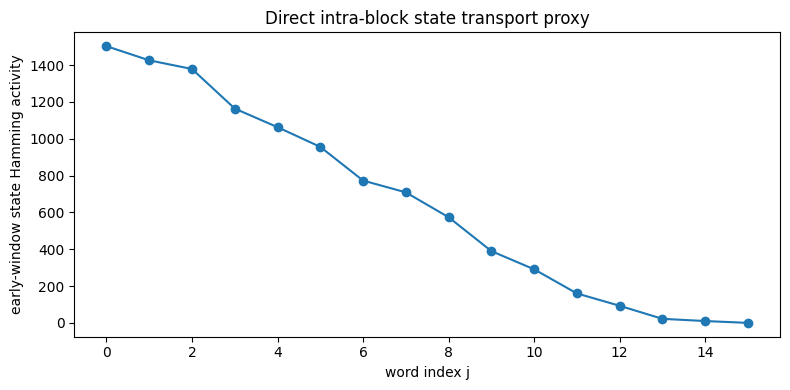

In [8]:

def hamming32(x: int) -> int:
    return int(x).bit_count()

def xor_state(a: List[int], b: List[int]) -> List[int]:
    return [u32(x ^ y) for x, y in zip(a, b)]

def state_hamming_weight(state: List[int]) -> int:
    return sum(hamming32(w) for w in state)

def early_window_energy_for_word(word_index: int, rounds: int = 20, window_end: int = 16) -> int:
    Wz = [0] * 64
    Wp = [0] * 64
    Wp[word_index] = 0xFFFFFFFF
    Sz = run_rounds(Wz, rounds=rounds)
    Sp = run_rounds(Wp, rounds=rounds)
    total = 0
    for r in range(1, min(window_end, len(Sz))):
        total += state_hamming_weight(xor_state(Sz[r], Sp[r]))
    return total

energies = [early_window_energy_for_word(j) for j in range(16)]
for j, e in enumerate(energies):
    print(f"W[{j:2d}] early-window energy = {e}")

plt.figure(figsize=(8,4))
plt.plot(range(16), energies, marker='o')
plt.xlabel("word index j")
plt.ylabel("early-window state Hamming activity")
plt.title("Direct intra-block state transport proxy")
plt.tight_layout()
plt.show()


## 9. State-space closure proxies — support exhaustion

Notebook proxy for **cumulative new-bit support** in the full 256-bit state.


per-round new support for W[0]:
[3, 21, 38, 49, 50, 37, 24, 14, 10, 5, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


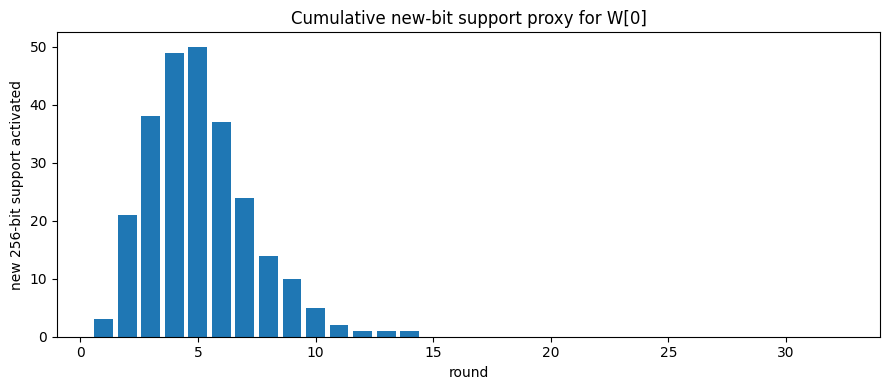

In [9]:

def flatten_state_bits(state: List[int]) -> np.ndarray:
    return np.concatenate([bits_of_word(w) for w in state], axis=0)

def cumulative_new_support_for_word(word_index: int, rounds: int = 64) -> List[int]:
    Wz = [0] * 64
    Wp = [0] * 64
    Wp[word_index] = 0xFFFFFFFF
    Sz = run_rounds(Wz, rounds=rounds)
    Sp = run_rounds(Wp, rounds=rounds)
    seen = np.zeros(256, dtype=np.uint8)
    cumul = []
    for r in range(1, rounds + 1):
        delta = flatten_state_bits(xor_state(Sz[r], Sp[r]))
        new = delta & (~seen & 1)
        seen |= delta
        cumul.append(int(new.sum()))
    return cumul

j = 0
cumul_new = cumulative_new_support_for_word(j, rounds=32)
print("per-round new support for W[0]:")
print(cumul_new)

plt.figure(figsize=(9,4))
plt.bar(range(1, len(cumul_new)+1), cumul_new)
plt.xlabel("round")
plt.ylabel("new 256-bit support activated")
plt.title("Cumulative new-bit support proxy for W[0]")
plt.tight_layout()
plt.show()


## 10. Schedule-space echoes

Measure the expanded schedule's direct echo amplitudes.


Schedule XOR-Hamming profile for W[0]:
[32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32, 0, 22, 0, 12, 0, 14, 32, 14, 22, 20, 11, 14, 14, 18, 15, 11, 18, 13, 18, 19, 14, 19, 16, 17, 15, 14, 19, 16, 16, 17, 19, 16, 17, 13, 18, 19, 15, 17, 16, 14, 13, 12, 17, 12, 15, 19, 13]


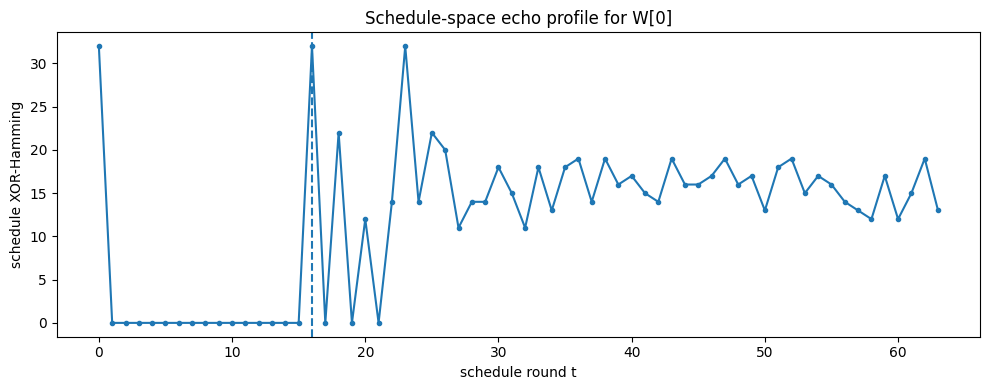

In [10]:

def schedule_echo_profile_for_word(j: int, width: int = 0xFFFFFFFF) -> List[int]:
    Wz = expand_schedule_from_w0_15([0]*16)
    w0_15 = [0]*16
    w0_15[j] = width
    Wp = expand_schedule_from_w0_15(w0_15)
    return [hamming32(u32(a ^ b)) for a, b in zip(Wz, Wp)]

j = 0
echo = schedule_echo_profile_for_word(j)
print("Schedule XOR-Hamming profile for W[0]:")
print(echo)

plt.figure(figsize=(10,4))
plt.plot(range(64), echo, marker='.')
plt.axvline(16, linestyle='--')
plt.xlabel("schedule round t")
plt.ylabel("schedule XOR-Hamming")
plt.title("Schedule-space echo profile for W[0]")
plt.tight_layout()
plt.show()


## 11. Path multiplicity scaffold

Track dependency counts through the standard schedule recurrence.


Path multiplicities for source W[0]:
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 3, 1, 4, 2, 6, 5, 8, 9, 10, 14, 13, 22, 20, 33, 32, 47, 50, 65, 78, 93, 122, 138, 186, 207, 275, 312, 403, 476, 594, 727, 880, 1099, 1307, 1645, 1954, 2454, 2941]


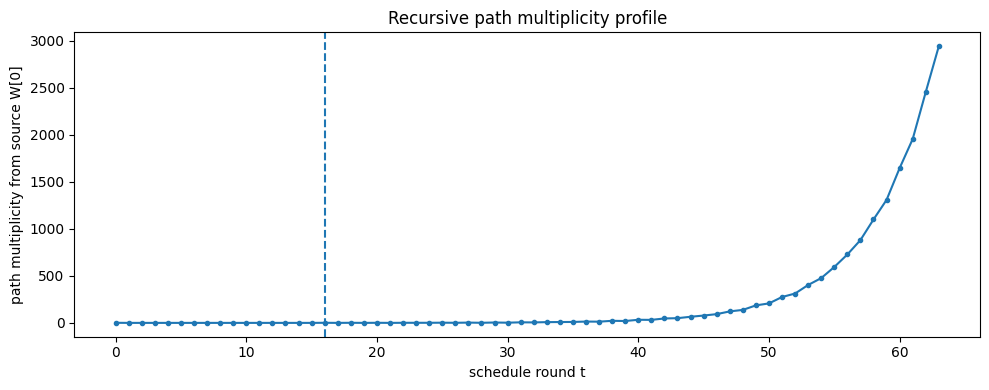

In [11]:

def path_multiplicity_matrix(T: int = 64, sources: int = 16) -> np.ndarray:
    P = np.zeros((sources, T), dtype=np.int64)
    for s in range(sources):
        P[s, s] = 1
    for t in range(16, T):
        P[:, t] = P[:, t-2] + P[:, t-7] + P[:, t-15] + P[:, t-16]
    return P

Pmat = path_multiplicity_matrix(64, 16)

j = 0
print("Path multiplicities for source W[0]:")
print(Pmat[j].tolist())

plt.figure(figsize=(10,4))
plt.plot(range(64), Pmat[j], marker='.')
plt.axvline(16, linestyle='--')
plt.xlabel("schedule round t")
plt.ylabel("path multiplicity from source W[0]")
plt.title("Recursive path multiplicity profile")
plt.tight_layout()
plt.show()


## 12. Capacity-gated projection law

Proxy model:

$$
\hat N_t = \alpha\, S_t\, C_t^\beta
$$

with transport-document discussion around

$$
\beta \approx 0.65.
$$


round  sched  capacity  new_support  projector_proxy
 1      32    0.9883        3        31.7557
 2       0    0.9062       21        0.0000
 3       0    0.7578       38        0.0000
 4       0    0.5664       49        0.0000
 5       0    0.3711       50        0.0000
 6       0    0.2266       37        0.0000
 7       0    0.1328       24        0.0000
 8       0    0.0781       14        0.0000
 9       0    0.0391       10        0.0000
10       0    0.0195        5        0.0000
11       0    0.0117        2        0.0000
12       0    0.0078        1        0.0000
13       0    0.0039        1        0.0000
14       0    0.0000        1        0.0000
15       0    0.0000        0        0.0000
16       0    0.0000        0        0.0000
17      32    0.0000        0        0.0000
18       0    0.0000        0        0.0000
19      22    0.0000        0        0.0000
20       0    0.0000        0        0.0000
21      12    0.0000        0        0.0000
22       0    0.0000  

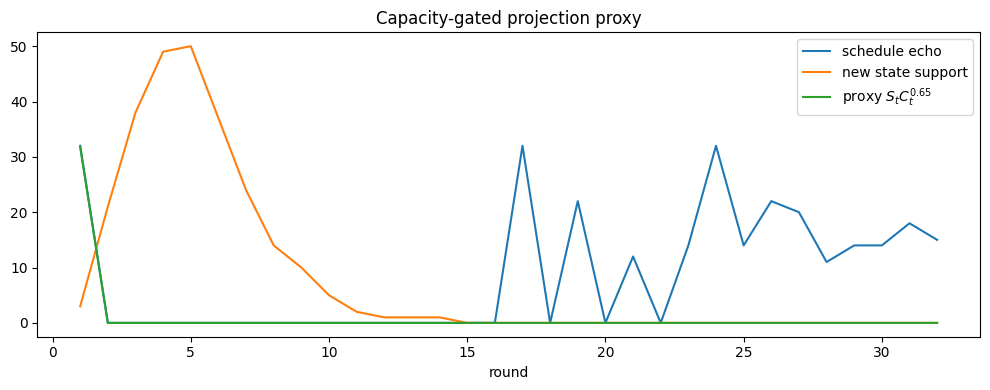

In [12]:

def state_capacity_profile_for_word(j: int, rounds: int = 32) -> Tuple[List[float], List[int]]:
    Wz = [0] * 64
    Wp = [0] * 64
    Wp[j] = 0xFFFFFFFF
    Sz = run_rounds(Wz, rounds=rounds)
    Sp = run_rounds(Wp, rounds=rounds)
    seen = np.zeros(256, dtype=np.uint8)
    caps = []
    newbits = []
    for r in range(1, rounds + 1):
        delta = flatten_state_bits(xor_state(Sz[r], Sp[r]))
        new = delta & (~seen & 1)
        seen |= delta
        caps.append(float(256 - int(seen.sum())) / 256.0)
        newbits.append(int(new.sum()))
    return caps, newbits

j = 0
rounds = 32
caps, newbits = state_capacity_profile_for_word(j, rounds=rounds)
sched = schedule_echo_profile_for_word(j)[:rounds]
beta = 0.65
alpha = 1.0
pred = [alpha * sched[t] * (caps[t] ** beta) for t in range(rounds)]

print("round  sched  capacity  new_support  projector_proxy")
for t in range(rounds):
    print(f"{t+1:2d}     {sched[t]:3d}    {caps[t]:.4f}      {newbits[t]:3d}        {pred[t]:.4f}")

plt.figure(figsize=(10,4))
plt.plot(range(1, rounds+1), sched, label="schedule echo")
plt.plot(range(1, rounds+1), newbits, label="new state support")
plt.plot(range(1, rounds+1), pred, label=r"proxy $S_t C_t^{0.65}$")
plt.xlabel("round")
plt.title("Capacity-gated projection proxy")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Four-stage layered transport model

1. **Entry** — staggered word injection creates a direct transport gradient  
2. **Branch** — schedule recurrence multiplies dependency paths  
3. **Saturate** — state capacity decays toward zero, suppressing new visible support  
4. **Reset** — block boundary simultaneity erases age structure while preserving magnitude

The closure statement is:

$$
\boxed{
\text{schedule echo} \not\Rightarrow \text{new visible state support}.
}
$$


## 14. Final notebook summary

This is the updated notebook bench:

- bare-metal rebuild
- seam / carry / seed-$B$
- GF(2) geometry
- augmented seam closure tests
- direct state transport proxy
- support exhaustion proxy
- schedule echo profiles
- path multiplicity scaffold
- capacity-gated projector proxy
